In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
print("tensorflow:", tf.__version__)

X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

tensorflow: 2.21.0
X_train: (242, 18)
X_test: (61, 18)
y_train: (242,)
y_test: (61,)


In [2]:
### input ( 18 features ) --> Dense (32 neuron) --> ReLu (activation fn) --> Dense (16) --> ReLu(activation fn) --> Dense (1) --> sigmoid ( converts the output between 0-1 )
## building the baseline model
model  = keras.Sequential([    ### sequential creates a empty model which process data through layers
    keras.layers.Input(shape=(18,)),
    keras.layers.Dense(32,activation="relu"),
    keras.layers.Dense(16,activation="relu"),
    keras.layers.Dense(1,activation="sigmoid")

])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
### model compiling
model.compile(   ### compile -- configures the learning of the model
    optimizer = "adam", ### optimizer updates the weight during training
    loss = "binary_crossentropy",  ### loss tells how wrong is the model prediction is
    metrics = ["accuracy"]
)

In [4]:
### training the model
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5648 - loss: 0.7026 - val_accuracy: 0.4490 - val_loss: 0.7219
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5855 - loss: 0.6554 - val_accuracy: 0.5102 - val_loss: 0.6872
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6580 - loss: 0.6300 - val_accuracy: 0.5714 - val_loss: 0.6659
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7047 - loss: 0.6089 - val_accuracy: 0.5714 - val_loss: 0.6499
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7254 - loss: 0.5912 - val_accuracy: 0.5918 - val_loss: 0.6363
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7461 - loss: 0.5733 - val_accuracy: 0.6327 - val_loss: 0.6084
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7565 - loss: 0.5580 - val_accuracy: 0.6939 - val_loss: 0.5867
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7565 - loss: 0.5408 - val_accuracy: 0.7143 - val_lo

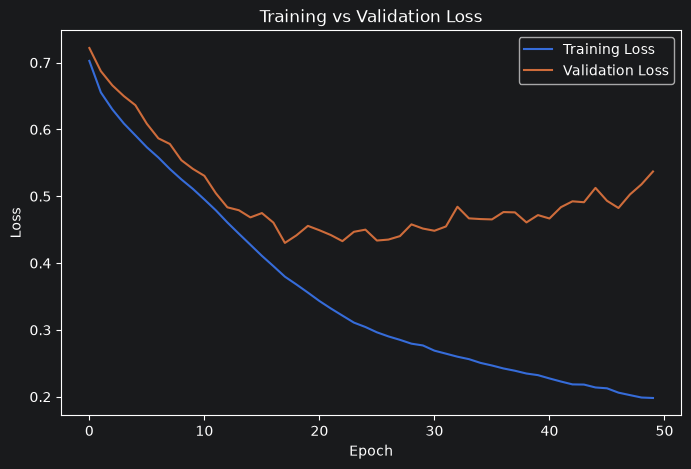

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

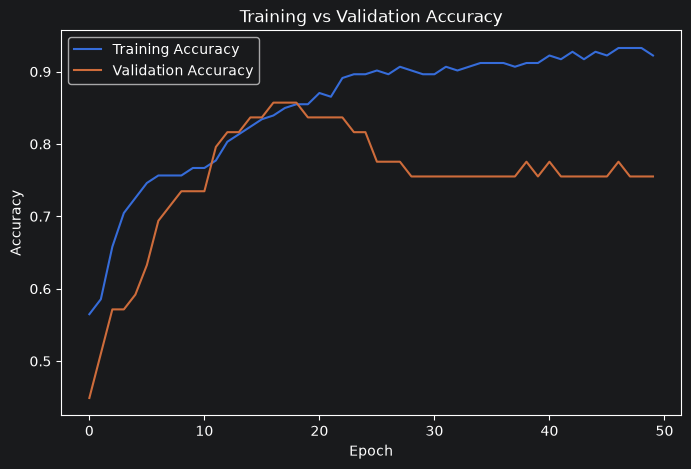

In [6]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

In [7]:
### early stopping call back
early_stopping = keras.callbacks.EarlyStopping(
    monitor = "val_loss",  ### which metrics to looks for
    patience = 5,    ### wait for 5 epoch if the val doesnt improve it stops
    restore_best_weights = True  ### restores the best weight
)

In [8]:
### training again with the changes
history_es = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9275 - loss: 0.1966 - val_accuracy: 0.7551 - val_loss: 0.5154
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9326 - loss: 0.1904 - val_accuracy: 0.7551 - val_loss: 0.5278
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9378 - loss: 0.1885 - val_accuracy: 0.7755 - val_loss: 0.5276
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9378 - loss: 0.1861 - val_accuracy: 0.7755 - val_loss: 0.5233
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9326 - loss: 0.1889 - val_accuracy: 0.7755 - val_loss: 0.4920
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9326 - loss: 0.1873 - val_accuracy: 0.7755 - val_loss: 0.5254
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9326 - loss: 0.1806 - val_accuracy: 0.7755 - val_loss: 0.5265
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9326 - loss: 0.1756 - val_accuracy: 0.7755 - val_loss: